# 📊 Painel de Análise de Vendas com Visualização de Dados
Projeto prático com **pandas, numpy, matplotlib e seaborn**.
Objetivo: consolidar dados de diferentes lojas e períodos, calcular métricas de desempenho e visualizar os resultados.

## Etapa 1 — Preparação e Importação de Dados

### 1) Importação das bibliotecas

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2) Carregamento do `vendas.csv`
Se o arquivo não existir na pasta, o código cria um dataset fictício (colunas: `data`, `loja`, `regiao`, `produto`, `categoria`, `quantidade`, `preco_unitario`).
> As colunas `regiao` e `categoria` foram acrescentadas porque os itens 13 e 15 pedem análises por região e por categoria.

In [2]:
if not os.path.exists('vendas.csv'):
    rng = np.random.default_rng(42)
    lojas = {'Loja Centro': 'Sudeste', 'Loja Savassi': 'Sudeste', 'Loja Porto Alegre': 'Sul',
             'Loja Recife': 'Nordeste', 'Loja Salvador': 'Nordeste', 'Loja Brasília': 'Centro-Oeste'}
    produtos = {'Notebook': ('Eletrônicos', 3200), 'Smartphone': ('Eletrônicos', 1800),
                'Fone de Ouvido': ('Acessórios', 150), 'Mouse': ('Acessórios', 70),
                'Teclado': ('Acessórios', 120), 'Monitor': ('Eletrônicos', 950),
                'Cadeira Gamer': ('Móveis', 850), 'Mesa de Escritório': ('Móveis', 600),
                'Webcam': ('Acessórios', 220), 'Impressora': ('Eletrônicos', 780)}
    n = 600
    datas = pd.to_datetime('2025-01-01') + pd.to_timedelta(rng.integers(0, 365, n), unit='D')
    loja = rng.choice(list(lojas), n)
    prod = rng.choice(list(produtos), n)
    df_novo = pd.DataFrame({
        'data': datas, 'loja': loja, 'regiao': [lojas[l] for l in loja],
        'produto': prod, 'categoria': [produtos[p][0] for p in prod],
        'quantidade': rng.integers(1, 10, n).astype(float),
        'preco_unitario': [round(produtos[p][1] * rng.uniform(0.9, 1.1), 2) for p in prod]})
    # insere alguns valores ausentes de propósito (para praticar o item 5)
    df_novo.loc[rng.choice(n, 15, replace=False), 'quantidade'] = np.nan
    df_novo.loc[rng.choice(n, 15, replace=False), 'preco_unitario'] = np.nan
    df_novo.sort_values('data').to_csv('vendas.csv', index=False)

df = pd.read_csv('vendas.csv')
df['data'] = pd.to_datetime(df['data'])   # converte para datetime
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario
0,2025-01-02,Loja Recife,Nordeste,Fone de Ouvido,Acessórios,7.0,161.70
1,2025-01-03,Loja Savassi,Sudeste,Webcam,Acessórios,3.0,209.33
2,2025-01-03,Loja Centro,Sudeste,Mesa de Escritório,Móveis,7.0,616.62
3,2025-01-03,Loja Salvador,Nordeste,Monitor,Eletrônicos,1.0,1029.31
4,2025-01-04,Loja Savassi,Sudeste,Fone de Ouvido,Acessórios,2.0,146.13


### 3) Coluna `faturamento` = quantidade × preco_unitario

In [3]:
df['faturamento'] = df['quantidade'] * df['preco_unitario']
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento
0,2025-01-02,Loja Recife,Nordeste,Fone de Ouvido,Acessórios,7.0,161.70,1131.90
1,2025-01-03,Loja Savassi,Sudeste,Webcam,Acessórios,3.0,209.33,627.99
2,2025-01-03,Loja Centro,Sudeste,Mesa de Escritório,Móveis,7.0,616.62,4316.34
3,2025-01-03,Loja Salvador,Nordeste,Monitor,Eletrônicos,1.0,1029.31,1029.31
4,2025-01-04,Loja Savassi,Sudeste,Fone de Ouvido,Acessórios,2.0,146.13,292.26


### 4) Integridade do dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            600 non-null    datetime64[us]
 1   loja            600 non-null    str           
 2   regiao          600 non-null    str           
 3   produto         600 non-null    str           
 4   categoria       600 non-null    str           
 5   quantidade      585 non-null    float64       
 6   preco_unitario  585 non-null    float64       
 7   faturamento     570 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 37.6 KB


In [5]:
print('Valores ausentes por coluna:')
df.isnull().sum()

Valores ausentes por coluna:


data               0
loja               0
regiao             0
produto            0
categoria          0
quantidade        15
preco_unitario    15
faturamento       30
dtype: int64

In [6]:
df.describe()

,data,quantidade,preco_unitario,faturamento
count,600,585.000000,585.000000,570.000000
mean,2025-07-02 04:12:00,4.899145,885.346906,4368.544789
min,2025-01-02 00:00:00,1.000000,63.810000,70.480000
25%,2025-03-31 18:00:00,3.000000,152.830000,682.335000
50%,2025-06-30 12:00:00,5.000000,653.420000,1904.160000
75%,2025-10-05 06:00:00,7.000000,954.950000,5672.220000
max,2025-12-31 00:00:00,9.000000,3493.450000,30497.760000
std,NaN,2.557238,931.321798,5900.415072


### 5) Tratamento de nulos
Preços e quantidades faltantes são substituídos pela média da respectiva coluna. Depois, o faturamento é recalculado para não ficar com `NaN`.

In [7]:
df['quantidade'] = df['quantidade'].fillna(df['quantidade'].mean())
df['preco_unitario'] = df['preco_unitario'].fillna(df['preco_unitario'].mean())
df['faturamento'] = df['quantidade'] * df['preco_unitario']   # recalcula
print('Nulos restantes:', df.isnull().sum().sum())

Nulos restantes: 0


## Etapa 2 — Análise Exploratória e Estatísticas

### 6) Faturamento total por loja (maior → menor)

In [8]:
fat_loja = df.groupby('loja')['faturamento'].sum().sort_values(ascending=False)
fat_loja.round(2)

loja
Loja Centro          486722.42
Loja Salvador        473648.51
Loja Brasília        472524.11
Loja Recife          472015.63
Loja Porto Alegre    380365.28
Loja Savassi         338754.87
Name: faturamento, dtype: float64

### 7) Ticket médio por loja (faturamento ÷ número de vendas)

In [9]:
ticket = (df.groupby('loja')['faturamento'].sum() / df.groupby('loja')['faturamento'].count()).sort_values(ascending=False)
ticket.round(2)

loja
Loja Centro          4680.02
Loja Brasília        4678.46
Loja Salvador        4643.61
Loja Recife          4140.49
Loja Savassi         4081.38
Loja Porto Alegre    3962.14
Name: faturamento, dtype: float64

### 8) Cinco produtos mais vendidos em quantidade

In [10]:
top5 = df.groupby('produto')['quantidade'].sum().sort_values(ascending=False).head(5)
top5.round(0)

produto
Impressora            329.0
Monitor               327.0
Notebook              317.0
Fone de Ouvido        305.0
Mesa de Escritório    305.0
Name: quantidade, dtype: float64

### 9) Mês de maior e menor faturamento (formato Mês/Ano)

In [11]:
meses_pt = {1:'Janeiro',2:'Fevereiro',3:'Março',4:'Abril',5:'Maio',6:'Junho',
            7:'Julho',8:'Agosto',9:'Setembro',10:'Outubro',11:'Novembro',12:'Dezembro'}
fat_mensal = df.groupby(df['data'].dt.to_period('M'))['faturamento'].sum()
fmt = lambda p: f"{meses_pt[p.month]}/{p.year}"
print(f"Maior faturamento: {fmt(fat_mensal.idxmax())} — R$ {fat_mensal.max():,.2f}")
print(f"Menor faturamento: {fmt(fat_mensal.idxmin())} — R$ {fat_mensal.min():,.2f}")

Maior faturamento: Fevereiro/2025 — R$ 294,345.16
Menor faturamento: Novembro/2025 — R$ 164,486.09


### 10) Coluna `mes` extraída da data

In [12]:
df['mes'] = df['data'].dt.month
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento,mes
0,2025-01-02,Loja Recife,Nordeste,Fone de Ouvido,Acessórios,7.0,161.70,1131.90,1
1,2025-01-03,Loja Savassi,Sudeste,Webcam,Acessórios,3.0,209.33,627.99,1
2,2025-01-03,Loja Centro,Sudeste,Mesa de Escritório,Móveis,7.0,616.62,4316.34,1
3,2025-01-03,Loja Salvador,Nordeste,Monitor,Eletrônicos,1.0,1029.31,1029.31,1
4,2025-01-04,Loja Savassi,Sudeste,Fone de Ouvido,Acessórios,2.0,146.13,292.26,1


## Etapa 3 — Visualizações com matplotlib e seaborn

### 17) Tema global (definido aqui para valer em **todos** os gráficos seguintes)
Definido antes dos gráficos para que o estilo seja aplicado a todos eles.

In [13]:
sns.set_style('whitegrid')
sns.set_palette(sns.color_palette('deep'))
os.makedirs('graficos', exist_ok=True)

### 11) Gráfico de barras — Faturamento por loja

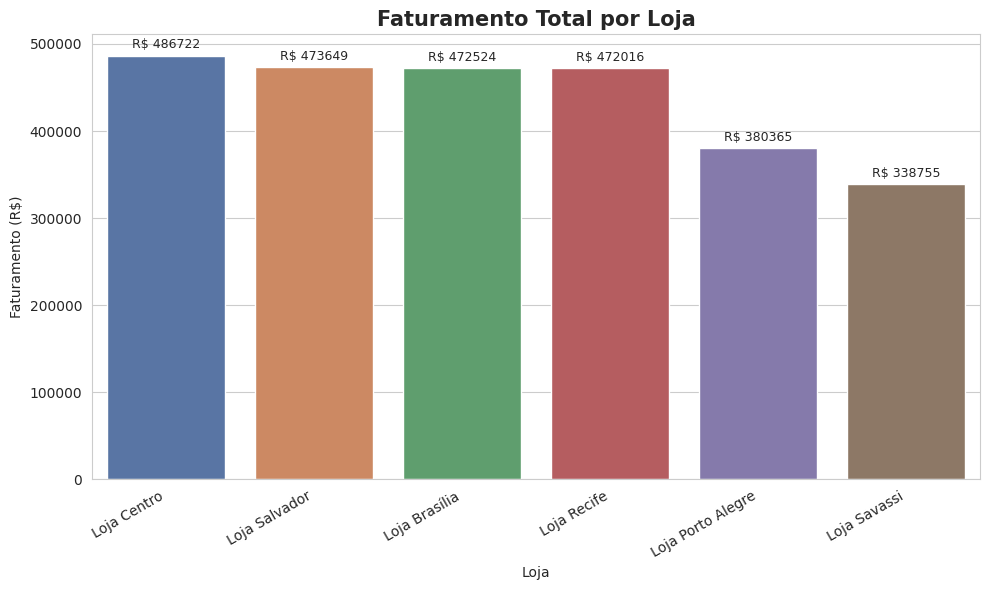

In [14]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=fat_loja.index, y=fat_loja.values, hue=fat_loja.index, palette='deep', legend=False)
for c in ax.containers:
    ax.bar_label(c, fmt='R$ %.0f', padding=3, fontsize=9)
plt.title('Faturamento Total por Loja', fontsize=15, weight='bold')
plt.xlabel('Loja'); plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('graficos/faturamento_por_loja.png', dpi=150)
plt.savefig('faturamento_por_loja.png', dpi=150)
plt.show()

### 12) Gráfico de linhas — Evolução mensal do faturamento

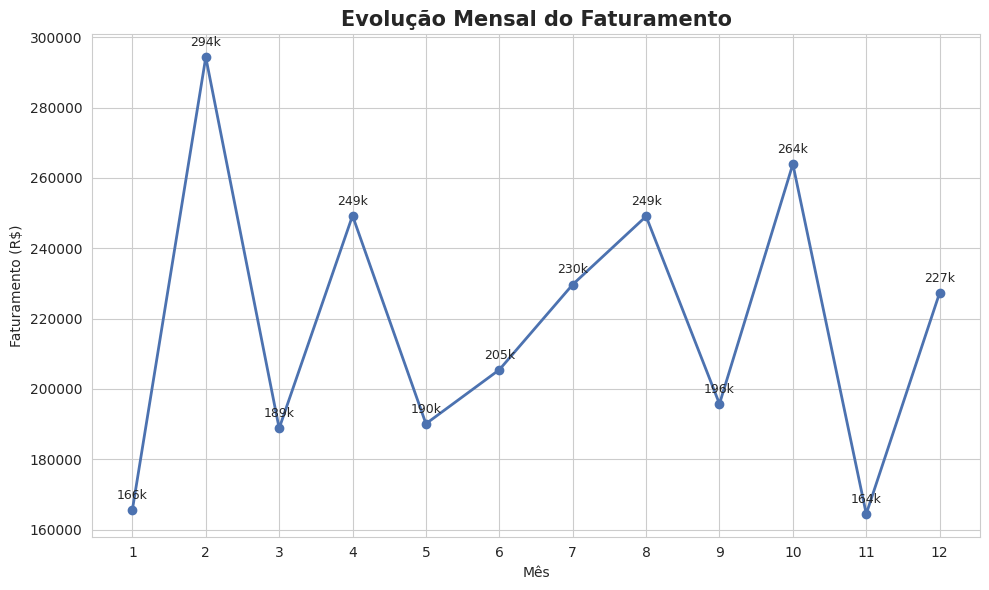

In [15]:
mensal = df.groupby('mes')['faturamento'].sum()
plt.figure(figsize=(10, 6))
plt.plot(mensal.index, mensal.values, marker='o', linewidth=2)
for x, y in zip(mensal.index, mensal.values):
    plt.annotate(f'{y/1000:.0f}k', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
plt.title('Evolução Mensal do Faturamento', fontsize=15, weight='bold')
plt.xlabel('Mês'); plt.ylabel('Faturamento (R$)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('graficos/evolucao_mensal.png', dpi=150)
plt.show()

### 13) Gráfico de pizza — Faturamento por região

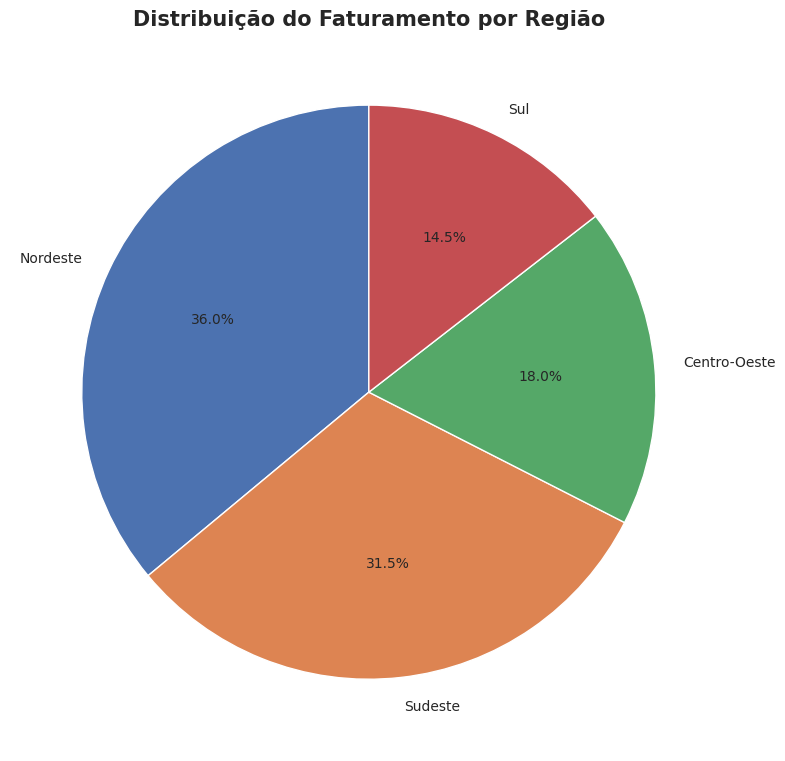

In [16]:
fat_regiao = df.groupby('regiao')['faturamento'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 8))
plt.pie(fat_regiao.values, labels=fat_regiao.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('deep', len(fat_regiao)), wedgeprops={'edgecolor': 'white'})
plt.title('Distribuição do Faturamento por Região', fontsize=15, weight='bold')
plt.tight_layout()
plt.savefig('graficos/faturamento_por_regiao_pizza.png', dpi=150)
plt.show()

### 14) Dispersão — Quantidade × Faturamento

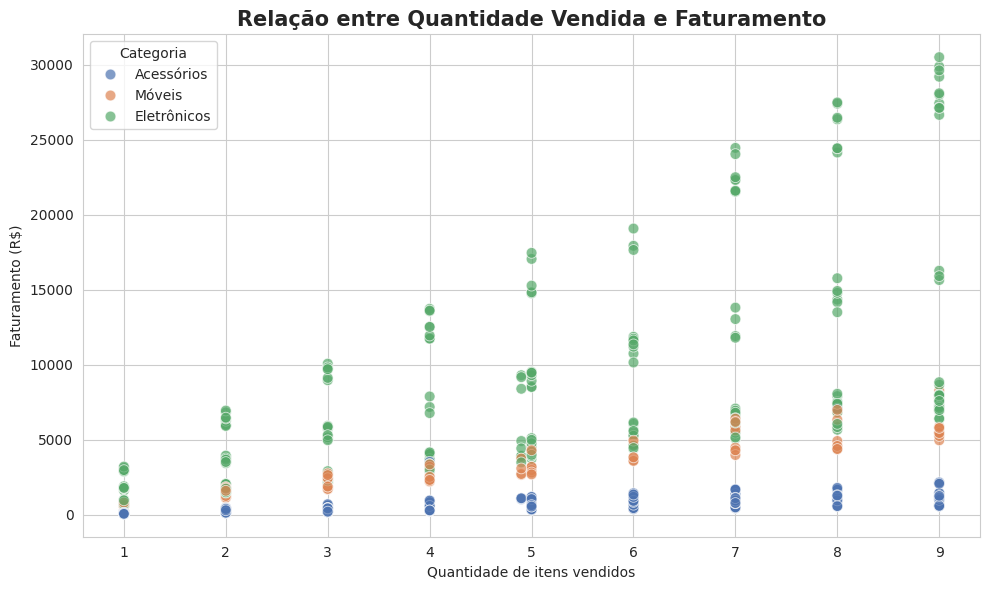

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='quantidade', y='faturamento', hue='categoria', alpha=0.7, s=60)
plt.title('Relação entre Quantidade Vendida e Faturamento', fontsize=15, weight='bold')
plt.xlabel('Quantidade de itens vendidos'); plt.ylabel('Faturamento (R$)')
plt.legend(title='Categoria')
plt.tight_layout()
plt.savefig('graficos/dispersao_quantidade_faturamento.png', dpi=150)
plt.show()

### 15) Boxplot — Preço unitário por categoria

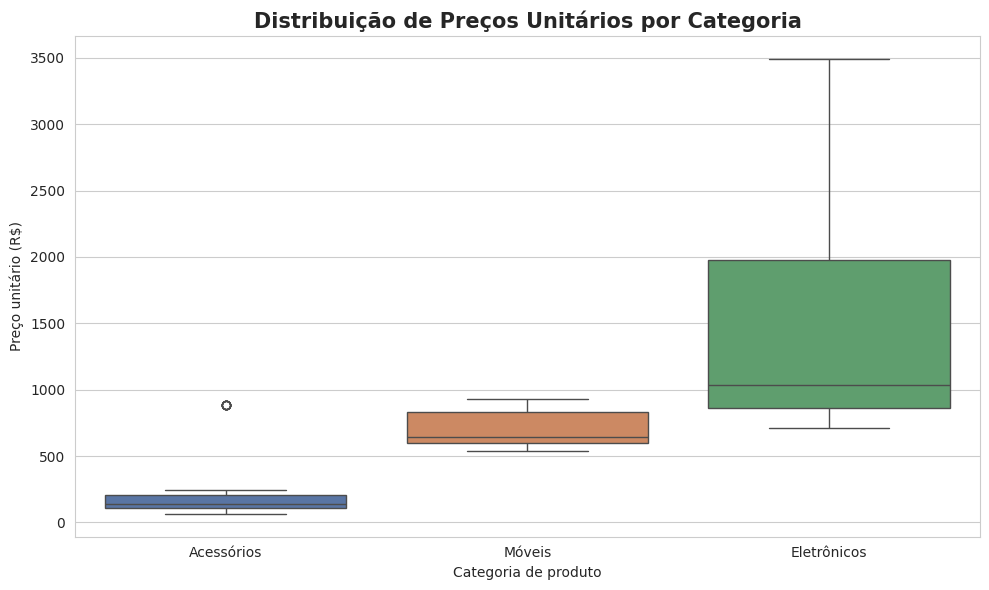

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='categoria', y='preco_unitario', hue='categoria', palette='deep', legend=False)
plt.title('Distribuição de Preços Unitários por Categoria', fontsize=15, weight='bold')
plt.xlabel('Categoria de produto'); plt.ylabel('Preço unitário (R$)')
plt.tight_layout()
plt.savefig('graficos/boxplot_preco_categoria.png', dpi=150)
plt.show()

### 16) Heatmap — Correlação entre variáveis numéricas

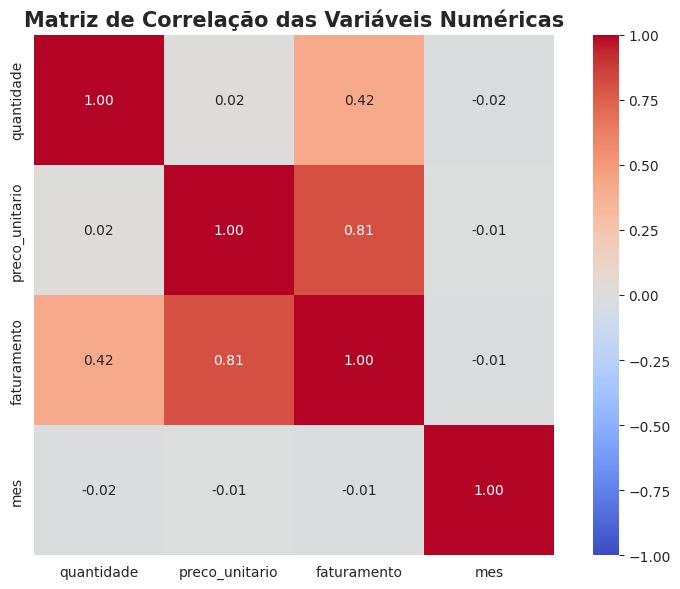

In [19]:
corr = df[['quantidade', 'preco_unitario', 'faturamento', 'mes']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=15, weight='bold')
plt.tight_layout()
plt.savefig('graficos/heatmap_correlacao.png', dpi=150)
plt.show()

## Etapa 4 — Estilização e Apresentação
### 17) Tema global
Já aplicado: `sns.set_style('whitegrid')` e `sns.color_palette('deep')`.

### 18) Rótulos e títulos
Todos os gráficos acima possuem título descritivo, rótulos de eixos e legendas legíveis (sem títulos genéricos como "Gráfico 1").

### 19) Layout com múltiplos gráficos (`plt.subplots`) — Loja × Região

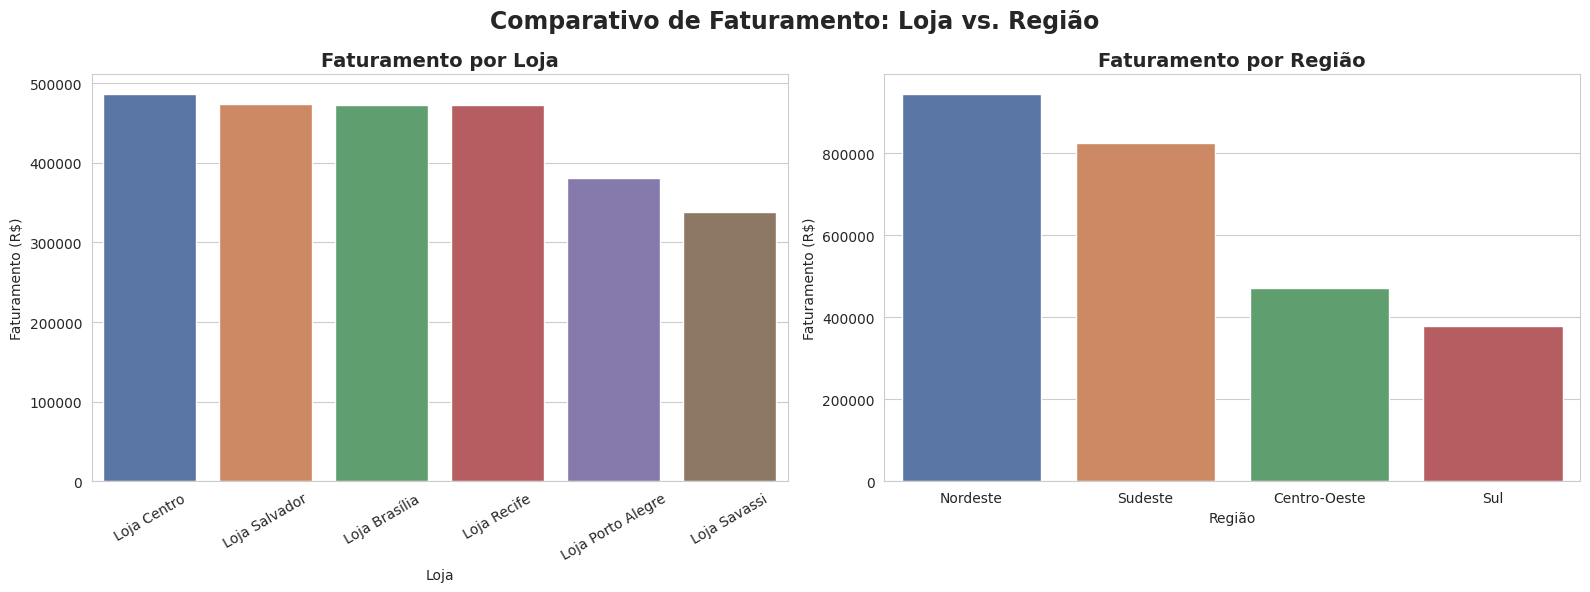

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=fat_loja.index, y=fat_loja.values, hue=fat_loja.index, palette='deep', legend=False, ax=axes[0])
axes[0].set_title('Faturamento por Loja', fontsize=14, weight='bold')
axes[0].set_xlabel('Loja'); axes[0].set_ylabel('Faturamento (R$)')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=fat_regiao.index, y=fat_regiao.values, hue=fat_regiao.index, palette='deep', legend=False, ax=axes[1])
axes[1].set_title('Faturamento por Região', fontsize=14, weight='bold')
axes[1].set_xlabel('Região'); axes[1].set_ylabel('Faturamento (R$)')

fig.suptitle('Comparativo de Faturamento: Loja vs. Região', fontsize=17, weight='bold')
plt.tight_layout()
plt.savefig('graficos/comparativo_loja_regiao.png', dpi=150)
plt.show()

### 20) Exportação e relatório final

In [21]:
# Todos os gráficos já foram salvos em graficos/. Agora o resumo analítico consolidado:
linhas = []
for loja, v in fat_loja.items():
    linhas.append(['Faturamento por loja', loja, round(v, 2)])
for loja, v in ticket.items():
    linhas.append(['Ticket médio por loja', loja, round(v, 2)])
for prod, v in top5.items():
    linhas.append(['Top 5 produtos (quantidade)', prod, round(v, 0)])
for reg, v in fat_regiao.items():
    linhas.append(['Faturamento por região', reg, round(v, 2)])
linhas.append(['Mês de maior faturamento', fmt(fat_mensal.idxmax()), round(fat_mensal.max(), 2)])
linhas.append(['Mês de menor faturamento', fmt(fat_mensal.idxmin()), round(fat_mensal.min(), 2)])

resumo = pd.DataFrame(linhas, columns=['metrica', 'item', 'valor'])
resumo.to_csv('resumo_analitico.csv', index=False, encoding='utf-8-sig')
print('Gráficos salvos:', sorted(os.listdir('graficos')))
resumo

Gráficos salvos: ['boxplot_preco_categoria.png', 'comparativo_loja_regiao.png', 'dispersao_quantidade_faturamento.png', 'evolucao_mensal.png', 'faturamento_por_loja.png', 'faturamento_por_regiao_pizza.png', 'heatmap_correlacao.png']


,metrica,item,valor
0,Faturamento por loja,Loja Centro,486722.42
1,Faturamento por loja,Loja Salvador,473648.51
2,Faturamento por loja,Loja Brasília,472524.11
3,Faturamento por loja,Loja Recife,472015.63
4,Faturamento por loja,Loja Porto Alegre,380365.28
5,Faturamento por loja,Loja Savassi,338754.87
6,Ticket médio por loja,Loja Centro,4680.02
7,Ticket médio por loja,Loja Brasília,4678.46
8,Ticket médio por loja,Loja Salvador,4643.61
9,Ticket médio por loja,Loja Recife,4140.49


## 📝 Observações finais (o que as visualizações mostram)

- **Lojas:** a *Loja Centro* lidera o faturamento (~R$ 487 mil), seguida de perto por Salvador, Brasília e Recife. *Loja Savassi* e *Porto Alegre* ficam atrás — as de menor faturamento e menor ticket médio.
- **Ticket médio:** Centro, Brasília e Salvador têm ticket acima de R$ 4.600; Porto Alegre tem o menor (~R$ 3.960), indicando vendas de itens mais baratos ou em menor quantidade.
- **Regiões:** o **Nordeste** concentra a maior fatia do faturamento (duas lojas), seguido do Sudeste; o Sul é a menor região.
- **Sazonalidade:** o melhor mês foi **Fevereiro/2025** e o pior **Novembro/2025**; o gráfico de linhas mostra oscilação relevante ao longo do ano.
- **Correlação:** o faturamento depende muito mais do **preço unitário** (r ≈ 0,81) do que da **quantidade** (r ≈ 0,42); quantidade e preço são praticamente independentes (r ≈ 0,02).
- **Categorias e outliers:** *Eletrônicos* têm preços bem mais altos e respondem por ~79% do faturamento, apesar de não serem a maioria das vendas; no scatter, os pontos mais altos (outliers) são de eletrônicos com quantidade elevada. *Acessórios* têm preços baixos e pouca dispersão.
- **Recomendação:** priorizar estoque/promoções de eletrônicos e investigar o que puxou fevereiro para cima e novembro para baixo, além de ações para elevar o ticket nas lojas de Porto Alegre e Savassi.

> Os dados são fictícios (gerados com `numpy`, semente 42), portanto as conclusões servem apenas para fins de prática.